In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
df = pd.read_excel("region_wise_sales.xlsx")
df

,Month,Year,Region,Sales
0,January,2022,APAC,36750
1,February,2022,APAC,36995
2,March,2022,APAC,18579
3,April,2022,APAC,37768
4,May,2022,APAC,23956
5,June,2022,APAC,38143
6,July,2022,APAC,29132
7,August,2022,APAC,21961
8,September,2022,APAC,33299
9,October,2022,APAC,37279


In [26]:
df.shape

(36, 4)

In [27]:
df.Region.unique()

array(['APAC', 'Europe', 'Americas'], dtype=object)

In [28]:
df_apac = df[df.Region == "APAC"]
df_apac

,Month,Year,Region,Sales
0,January,2022,APAC,36750
1,February,2022,APAC,36995
2,March,2022,APAC,18579
3,April,2022,APAC,37768
4,May,2022,APAC,23956
5,June,2022,APAC,38143
6,July,2022,APAC,29132
7,August,2022,APAC,21961
8,September,2022,APAC,33299
9,October,2022,APAC,37279


In [29]:
df_Europe = df[df.Region == "Europe"]
df_Europe

,Month,Year,Region,Sales
12,January,2022,Europe,9665
13,February,2022,Europe,10297
14,March,2022,Europe,11079
15,April,2022,Europe,13410
16,May,2022,Europe,11229
17,June,2022,Europe,15352
18,July,2022,Europe,13286
19,August,2022,Europe,11470
20,September,2022,Europe,11873
21,October,2022,Europe,23000


In [30]:
df_Americas = df[df.Region == "Americas"]
df_Americas

,Month,Year,Region,Sales
24,January,2022,Americas,30247
25,February,2022,Americas,29284
26,March,2022,Americas,27904
27,April,2022,Americas,23407
28,May,2022,Americas,23716
29,June,2022,Americas,25077
30,July,2022,Americas,33649
31,August,2022,Americas,24560
32,September,2022,Americas,34102
33,October,2022,Americas,28257


In [31]:
def get_lower_upper(data):
    Q1,Q3 = data.Sales.quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return lower,upper

In [34]:
lower , upper = get_lower_upper(df_Europe)
lower , upper

(7306.875, 17665.875)

In [35]:
df_Europe.describe()


,Year,Sales
count,12.0,12.000000
mean,2022.0,13147.583333
std,0.0,3549.568795
min,2022.0,9665.000000
25%,2022.0,11191.500000
50%,2022.0,12044.000000
75%,2022.0,13781.250000
max,2022.0,23000.000000


In [38]:
df_Europe[(df_Europe.Sales >upper)]

,Month,Year,Region,Sales
21,October,2022,Europe,23000


In [39]:
lower , upper = get_lower_upper(df_Americas)
lower , upper

(16832.375, 38473.375)

In [40]:
df_Americas.describe()

,Year,Sales
count,12.0,12.000000
mean,2022.0,28356.750000
std,0.0,3610.368556
min,2022.0,23407.000000
25%,2022.0,24947.750000
50%,2022.0,28770.500000
75%,2022.0,30358.000000
max,2022.0,34102.000000


In [41]:
df_Americas[(df_Americas.Sales <lower) | (df_Americas.Sales > upper)]

,Month,Year,Region,Sales


In [42]:
labels = df['Region'].unique()
labels

array(['APAC', 'Europe', 'Americas'], dtype=object)

In [43]:
plot_data = [df['Sales'][df['Region'] == label].values for label in labels]
plot_data

[array([36750, 36995, 18579, 37768, 23956, 38143, 29132, 21961, 33299,
        37279, 21388, 21896]),
 array([ 9665, 10297, 11079, 13410, 11229, 15352, 13286, 11470, 11873,
        23000, 12215, 14895]),
 array([30247, 29284, 27904, 23407, 23716, 25077, 33649, 24560, 34102,
        28257, 30691, 29387])]

C:\Users\KIIT\AppData\Local\Temp\ipykernel_14224\479961180.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=labels, vert=True, patch_artist=True)


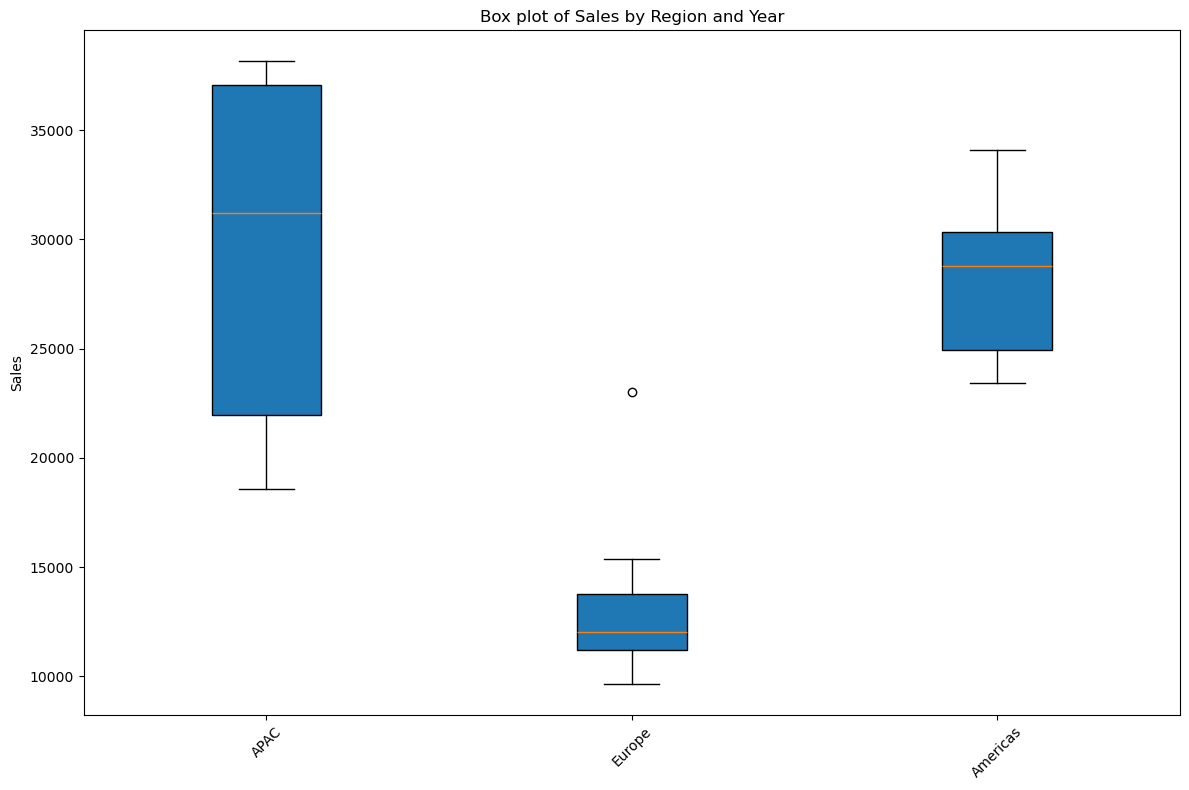

In [44]:
plt.figure(figsize=(12, 8))
plt.boxplot(plot_data, labels=labels, vert=True, patch_artist=True)
plt.title('Box plot of Sales by Region and Year')
plt.ylabel('Sales')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()